# Notebook 12 — Periodic Systems & Phonons

**MOLEKUL | Phases 20a–20c, 21, 22, 23**

---

Solid-state physics and materials science operate on **periodic** systems — infinite
crystals described by a unit cell repeated in one, two, or three dimensions.
The Bloch theorem reduces the infinite problem to a finite one at each **k-point**
in the Brillouin zone.

MOLEKUL implements the full periodic quantum chemistry stack:

| Phase | Capability |
|-------|----------|
| 20a | Periodic infrastructure: `Crystal`, Bloch sums |
| 20b | Periodic HF (H chain, 1D, real-space cutoff SCF) |
| 20c | Ewald summation for 3D electrostatics |
| 21 | Band structures (H chain + LiH) |
| 22 | Density of states + nuclear-only phonons |
| 23 | Full phonons (nuclear + electronic, from SCF energy FD) |

**What you will learn:**
1. The `Crystal` data structure and the Bloch theorem.
2. Bloch sums of Gaussian basis functions.
3. Band structure along high-symmetry paths.
4. The density of states and Fermi level.
5. The dynamical matrix and phonon dispersion curves.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.periodic import (
    Crystal, monkhorst_pack,
    bloch_overlap, bloch_hcore, ewald_energy,
    band_structure, kpath,
    dos,
    phonon_band_structure, phonon_band_structure_full,
    periodic_hf,
)
from molekul.basis_sto3g import STO3G
from molekul.constants import BOHR_TO_ANGSTROM, HARTREE_TO_EV

print("Imports OK")

Imports OK


## 1. The `Crystal` data structure

A `Crystal` is defined by:
- `lattice` — an array of shape `(ndim, 3)` giving the $d$ lattice vectors in Bohr.
  $d = 1$ for 1D (chain), $d = 2$ for 2D (slab), $d = 3$ for 3D (bulk).
- `atoms` — list of `Atom` objects with coordinates in Bohr.
- `charge`, `multiplicity` — same as `Molecule`.

The **reciprocal lattice** is computed from the lattice vectors:
$$\mathbf{b}_i = 2\pi \frac{\mathbf{a}_j \times \mathbf{a}_k}{\mathbf{a}_1 \cdot (\mathbf{a}_2 \times \mathbf{a}_3)}$$

The **Brillouin zone** (BZ) is the Wigner-Seitz cell of the reciprocal lattice.
Integrals over the BZ are replaced by sums over **k-points**.

In [2]:
# H chain: 2 H atoms per unit cell (closed-shell), spacing = 2.0 Bohr
a = 4.0  # unit cell length in Bohr (2 H atoms at 0 and a/2)
h_chain = Crystal(
    lattice=np.array([[a, 0.0, 0.0]]),
    atoms=[
        Atom('H', np.array([0.0, 0.0, 0.0])),
        Atom('H', np.array([a/2, 0.0, 0.0])),
    ],
    name='H chain',
)
print(h_chain)
print(f'\nUnit cell: {a:.2f} Bohr = {a*BOHR_TO_ANGSTROM:.4f} \u00c5 (2 H at 0 and {a/2:.1f} Bohr)')
print(f'Reciprocal lattice: {h_chain.reciprocal_lattice}')
print(f'n_electrons per cell: {h_chain.n_electrons}')


Crystal(lattice=array([[4., 0., 0.]]), atoms=[Atom(H, Z=1, xyz=[0.000000, 0.000000, 0.000000] Å), Atom(H, Z=1, xyz=[1.058354, 0.000000, 0.000000] Å)], charge=0, multiplicity=1, name='H chain')

Unit cell: 4.00 Bohr = 2.1167 Å (2 H at 0 and 2.0 Bohr)
Reciprocal lattice: [[1.57079633 0.         0.        ]]
n_electrons per cell: 2


## 2. The Bloch theorem and Bloch sums

The Bloch theorem states that in a periodic potential, each eigenfunction has the form:
$$\psi_{n\mathbf{k}}(\mathbf{r}) = e^{i\mathbf{k}\cdot\mathbf{r}} u_{n\mathbf{k}}(\mathbf{r})$$

where $u_{n\mathbf{k}}$ has the same periodicity as the lattice and $\mathbf{k}$ is the
crystal momentum confined to the first Brillouin zone.

In a Gaussian basis, we build **Bloch-sum basis functions**:
$$\phi_\mu^{\mathbf{k}}(\mathbf{r}) = \sum_{\mathbf{R}} e^{i\mathbf{k}\cdot\mathbf{R}} \phi_\mu(\mathbf{r} - \mathbf{R})$$

The overlap and core Hamiltonian matrices at wavevector $\mathbf{k}$ are:
$$S_{\mu\nu}(\mathbf{k}) = \sum_{\mathbf{R}} e^{i\mathbf{k}\cdot\mathbf{R}} S_{\mu\nu}(\mathbf{R})$$

The secular equation $\mathbf{H}(\mathbf{k})\mathbf{C}(\mathbf{k}) = \mathbf{S}(\mathbf{k})\mathbf{C}(\mathbf{k})\boldsymbol{\varepsilon}(\mathbf{k})$
is solved at each $\mathbf{k}$ independently.

In [3]:
basis = STO3G
sp = {'G': np.array([0.0, 0.0, 0.0]), 'X': np.array([np.pi/a, 0.0, 0.0])}

# At Gamma and X only
kpoints_2 = np.array([[0.0, 0.0, 0.0], [np.pi/a, 0.0, 0.0]])
S_k = bloch_overlap(h_chain, basis, kpoints_2)
H_k = bloch_hcore(h_chain, basis, kpoints_2)

print(f'S(k) shape: {S_k.shape}  — (n_kpoints, n_basis, n_basis)')
print(f'\nS(\u0393) =\n{S_k[0].real}')
print(f'S(X) =\n{S_k[1].real}')


S(k) shape: (2, 2, 2)  — (n_kpoints, n_basis, n_basis)

S(Γ) =
[[1.19819319 0.95070438]
 [0.95070438 1.19819319]]
S(X) =
[[8.05657246e-01 2.60654719e-13]
 [2.60678348e-13 8.05657246e-01]]


## 3. Band structure of the H chain

The **band structure** plots the eigenvalues $\varepsilon_n(\mathbf{k})$ along a
high-symmetry path in the BZ.

Our unit cell holds **two** H atoms, so STO-3G gives **two** Bloch basis functions
and the band structure has **two bands**. At each $\mathbf{k}$ they are the in-phase
(bonding) and out-of-phase (antibonding) combinations of the two atomic 1s functions —
exactly the $\sigma$ / $\sigma^*$ molecular orbitals of H₂, now broadened into bands by
the crystal momentum. With 2 electrons per cell the lower (bonding) band is completely
filled and the upper (antibonding) band is empty, separated by a gap that is narrowest
at the zone boundary $X$.

> **A caveat worth stating.** An *ideal* infinite chain of equally spaced H atoms is
> famously a half-filled **metal** — one electron in one orbital per *primitive* cell.
> The gap you see below is partly an artifact of describing that chain with a doubled,
> two-atom cell, and partly of the minimal STO-3G basis with the short real-space
> lattice cutoff these teaching routines use (see `SCIENCE.md`). Read this section as
> *"how a 1D band is assembled from atomic orbitals"*, not as a converged prediction of
> the metallicity of hydrogen. The LiH chain in the next section is a genuine insulator
> where the gap is physical.

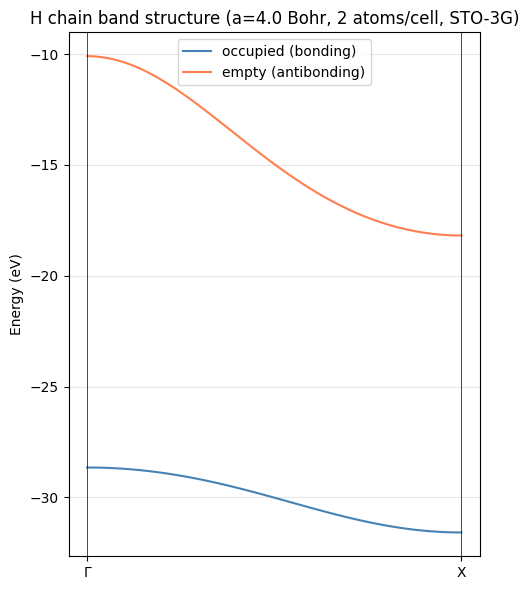

Lower (bonding) band width:     2.931 eV
Upper (antibonding) band width: 8.094 eV
Bonding-antibonding gap at X:   13.397 eV


In [4]:
# kpath(crystal, special_points_dict, path_string, n_points)
sp = {'G': np.array([0.0, 0.0, 0.0]), 'X': np.array([np.pi/a, 0.0, 0.0])}

bsr = band_structure(h_chain, STO3G, sp, 'G-X', n_points=50)
bands_eV = bsr.band_energies * HARTREE_TO_EV   # (n_k, n_bands)
n_occ_bands = h_chain.n_electrons // 2         # filled bands per cell (= 1 here)

fig, ax = plt.subplots(figsize=(5, 6))
for band in range(bands_eV.shape[1]):
    occupied = band < n_occ_bands
    ax.plot(bsr.x_coords, bands_eV[:, band],
            color='steelblue' if occupied else 'coral',
            label=('occupied (bonding)' if band == 0
                   else 'empty (antibonding)' if band == n_occ_bands else None))

for xt in bsr.tick_positions:
    ax.axvline(xt, color='k', lw=0.5)
ax.set_xticks(bsr.tick_positions)
ax.set_xticklabels(bsr.tick_labels)
ax.set_ylabel('Energy (eV)')
ax.set_title(f'H chain band structure (a={a} Bohr, 2 atoms/cell, STO-3G)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

gap_X = bands_eV[-1, n_occ_bands] - bands_eV[-1, n_occ_bands - 1]
print(f'Lower (bonding) band width:     {np.ptp(bands_eV[:,0]):.3f} eV')
print(f'Upper (antibonding) band width: {np.ptp(bands_eV[:,1]):.3f} eV')
print(f'Bonding-antibonding gap at X:   {gap_X:.3f} eV')

## 4. Band structure of LiH (1D)

A two-atom unit cell (LiH diatomic chain) gives two bands — one filled (bonding)
and one empty (antibonding). LiH is an ionic insulator: the HOMO-LUMO gap
at the one-electron level corresponds to a charge-transfer excitation.

In [5]:
a_lih = 6.0  # Bohr
d_LiH = 3.015 / 2

lih_chain = Crystal(
    lattice=np.array([[a_lih, 0.0, 0.0]]),
    atoms=[
        Atom('Li', np.array([-d_LiH, 0.0, 0.0])),
        Atom('H',  np.array([+d_LiH, 0.0, 0.0])),
    ],
    name='LiH chain',
)
print(lih_chain)
print(f'n_electrons per cell: {lih_chain.n_electrons}')
print(f'STO-3G basis functions per cell: {len(STO3G.basis_functions(lih_chain))}')


Crystal(lattice=array([[6., 0., 0.]]), atoms=[Atom(Li, Z=3, xyz=[-0.797735, 0.000000, 0.000000] Å), Atom(H, Z=1, xyz=[0.797735, 0.000000, 0.000000] Å)], charge=0, multiplicity=1, name='LiH chain')
n_electrons per cell: 4
STO-3G basis functions per cell: 6


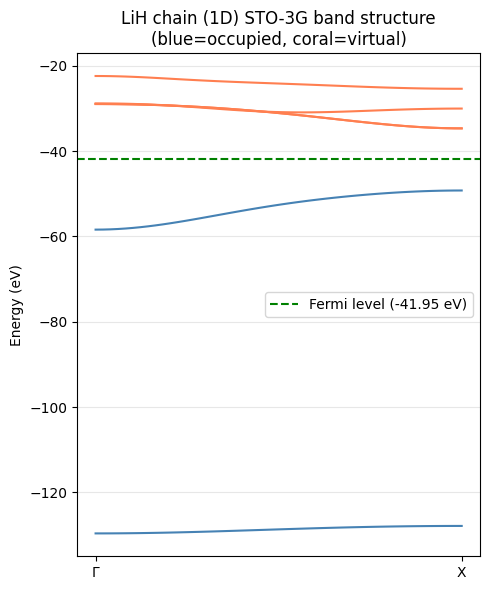

One-electron gap: 14.564 eV


In [6]:
sp_lih = {'G': np.array([0.0, 0.0, 0.0]), 'X': np.array([np.pi/a_lih, 0.0, 0.0])}

bsr_lih = band_structure(lih_chain, STO3G, sp_lih, 'G-X', n_points=50)
bands_lih = bsr_lih.band_energies * HARTREE_TO_EV

n_occ_per_cell = lih_chain.n_electrons // 2

fig, ax = plt.subplots(figsize=(5, 6))
for band in range(bands_lih.shape[1]):
    color = 'steelblue' if band < n_occ_per_cell else 'coral'
    ax.plot(bsr_lih.x_coords, bands_lih[:, band], color=color)

E_f = 0.5 * (bands_lih[:, n_occ_per_cell-1].max() + bands_lih[:, n_occ_per_cell].min())
ax.axhline(E_f, ls='--', color='green', lw=1.5, label=f'Fermi level ({E_f:.2f} eV)')

ax.set_xticks(bsr_lih.tick_positions)
ax.set_xticklabels(bsr_lih.tick_labels)
ax.set_ylabel('Energy (eV)')
ax.set_title('LiH chain (1D) STO-3G band structure\n(blue=occupied, coral=virtual)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

gap = bands_lih[:, n_occ_per_cell].min() - bands_lih[:, n_occ_per_cell-1].max()
print(f'One-electron gap: {gap:.3f} eV')


## 5. Density of States

The **density of states** (DOS) is:
$$g(\varepsilon) = \sum_{n,\mathbf{k}} \delta(\varepsilon - \varepsilon_{n\mathbf{k}})$$

In practice, the delta functions are broadened with Gaussians:
$$g(\varepsilon) \approx \sum_{n,\mathbf{k}} \frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{(\varepsilon - \varepsilon_{n\mathbf{k}})^2}{2\sigma^2}\right]$$

The integral $\int g(\varepsilon)d\varepsilon = N_{\text{bands}} \times N_k$ (total state count).
The DOS at the Fermi level $g(\varepsilon_F)$ determines electrical conductivity.

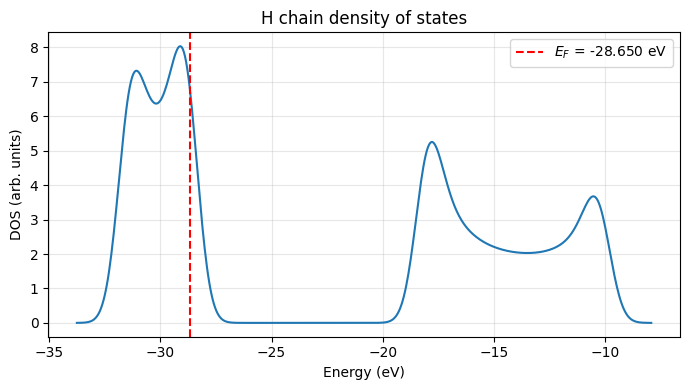

Fermi level: -28.6497 eV


In [7]:
kpoints_dense = monkhorst_pack(h_chain.lattice, mesh=(20,))
bsr_dense = band_structure(h_chain, STO3G, sp, 'G-X', n_points=100)

dos_result = dos(bsr_dense, n_grid=500, sigma=0.02)

fig, ax = plt.subplots(figsize=(7, 4))
energies_eV = dos_result.energies * HARTREE_TO_EV
ax.plot(energies_eV, dos_result.dos)
ax.axvline(dos_result.e_fermi * HARTREE_TO_EV, ls='--', color='red',
           label=f'$E_F$ = {dos_result.e_fermi*HARTREE_TO_EV:.3f} eV')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('DOS (arb. units)')
ax.set_title('H chain density of states')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Fermi level: {dos_result.e_fermi*HARTREE_TO_EV:.4f} eV')


## 6. Phonons: lattice dynamics

**Phonons** are the quantised normal modes of lattice vibrations — the periodic
equivalent of molecular vibrational frequencies.

### Dynamical matrix

The **dynamical matrix** at wavevector $\mathbf{q}$ is the mass-weighted Fourier
transform of the force constant matrix:

$$D_{\alpha\beta}^{AB}(\mathbf{q}) = \sum_{\mathbf{R}}
\frac{\Phi_{\alpha\beta}^{A0,BR}}{\sqrt{m_A m_B}} e^{i\mathbf{q}\cdot\mathbf{R}}$$

where $\Phi_{\alpha\beta}^{A0,BR} = \partial^2 E / \partial u_{A\alpha}^0 \partial u_{B\beta}^R$
are the interatomic force constants.

Phonon frequencies $\omega(\mathbf{q})$ are the square roots of the eigenvalues
of $\mathbf{D}(\mathbf{q})$.

### Phase 22: nuclear-only phonons

MOLEKUL Phase 22 uses the **nuclear repulsion energy** only to compute force constants —
a pedagogical approximation that captures the qualitative picture without a full
periodic SCF at each displaced geometry.

### Phase 23: full phonons

Phase 23 uses the **total periodic HF energy** (from `periodic_hf()`) for finite-difference
force constants, giving the full electronic + nuclear contribution.

Computing nuclear-only phonon dispersion...


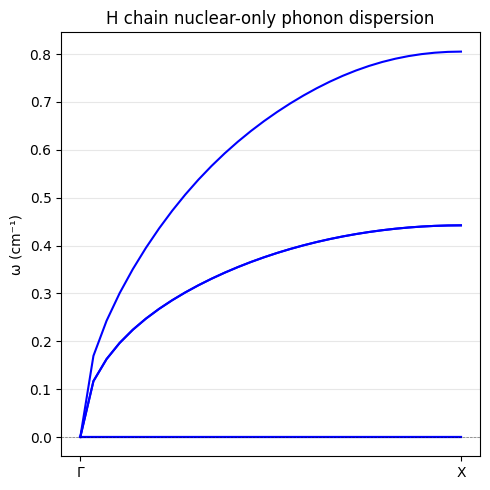

Acoustic mode at Γ: 0.0000 cm⁻¹  (should ≈ 0)
Max frequency at X:  0.0 cm⁻¹


In [8]:
sp_ph = {'G': np.array([0.0, 0.0, 0.0]), 'X': np.array([np.pi/a, 0.0, 0.0])}

print('Computing nuclear-only phonon dispersion...')
phon_nuc = phonon_band_structure(h_chain, STO3G, sp_ph, 'G-X', n_points=30, h=1e-2)

fig, ax = plt.subplots(figsize=(5, 5))
for mode in range(phon_nuc.frequencies.shape[1]):
    ax.plot(phon_nuc.x_coords, phon_nuc.frequencies[:, mode], 'b-')

ax.axhline(0, ls='--', color='k', lw=0.5, alpha=0.5)
ax.set_xticks(phon_nuc.tick_positions)
ax.set_xticklabels(phon_nuc.tick_labels)
ax.set_ylabel('\u03c9 (cm\u207b\u00b9)')
ax.set_title('H chain nuclear-only phonon dispersion')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print(f'Acoustic mode at \u0393: {phon_nuc.frequencies[0, 0]:.4f} cm\u207b\u00b9  (should \u2248 0)')
print(f'Max frequency at X:  {phon_nuc.frequencies[-1, 0]:.1f} cm\u207b\u00b9')


Computing full periodic-HF phonon dispersion (Phase 23)...


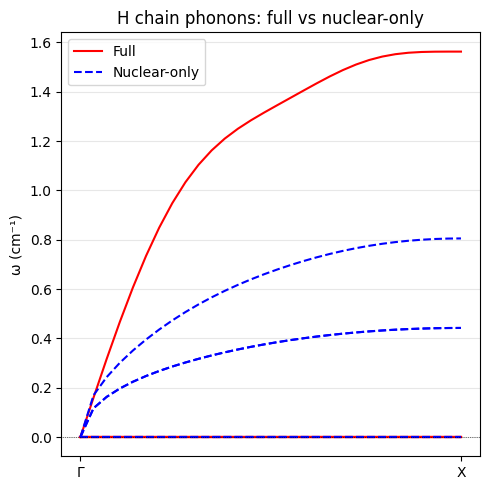

Full  Γ acoustic: 0.0000e+00 cm⁻¹
Nuclear Γ acoustic: 0.0000e+00 cm⁻¹


In [9]:
sp_ph = {'G': np.array([0.0, 0.0, 0.0]), 'X': np.array([np.pi/a, 0.0, 0.0])}

print('Computing full periodic-HF phonon dispersion (Phase 23)...')
phon_full = phonon_band_structure_full(h_chain, STO3G, sp_ph, 'G-X', n_points=30)

fig, ax = plt.subplots(figsize=(5, 5))
for mode in range(phon_full.frequencies.shape[1]):
    ax.plot(phon_full.x_coords, phon_full.frequencies[:, mode], 'r-',
            label='Full' if mode == 0 else None)
for mode in range(phon_nuc.frequencies.shape[1]):
    ax.plot(phon_nuc.x_coords, phon_nuc.frequencies[:, mode], 'b--',
            label='Nuclear-only' if mode == 0 else None)

ax.axhline(0, ls=':', color='k', lw=0.5)
ax.set_xticks(phon_full.tick_positions)
ax.set_xticklabels(phon_full.tick_labels)
ax.set_ylabel('\u03c9 (cm\u207b\u00b9)')
ax.set_title('H chain phonons: full vs nuclear-only')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print(f'Full  \u0393 acoustic: {phon_full.frequencies[0, 0]:.4e} cm\u207b\u00b9')
print(f'Nuclear \u0393 acoustic: {phon_nuc.frequencies[0, 0]:.4e} cm\u207b\u00b9')


## 7. The Ewald summation

In 3D periodic systems, the nuclear repulsion energy is a conditionally convergent sum:
$$E_{\text{nuc}} = \frac{1}{2}\sum_{A,B,\mathbf{R}}^{\prime} \frac{Z_A Z_B}{|\mathbf{R} + \tau_{AB}|}$$

The **Ewald method** accelerates convergence by splitting into short-range (real space)
and long-range (reciprocal space) contributions:
$$E_{\text{Ewald}} = E_{\text{real}} + E_{\text{recip}} + E_{\text{self}} + E_{\text{net}}$$

The splitting parameter $\eta$ controls the relative convergence of the two sums;
MOLEKUL chooses it automatically based on the lattice geometry.

In [10]:
# Ewald energy for a 3D LiH crystal (rock-salt structure)
a_lih3d = 7.608  # LiH experimental lattice constant in Bohr

lih_3d = Crystal(
    lattice=np.array([
        [a_lih3d, 0.0, 0.0],
        [0.0, a_lih3d, 0.0],
        [0.0, 0.0, a_lih3d],
    ]),
    atoms=[
        Atom("Li", np.array([0.0, 0.0, 0.0])),
        Atom("H",  np.array([a_lih3d/2, a_lih3d/2, a_lih3d/2])),
    ],
    name="LiH cubic",
)

E_ewald = ewald_energy(lih_3d)
print(f"LiH (cubic, a={a_lih3d:.3f} Bohr) Ewald nuclear energy:")
print(f"  E_Ewald = {E_ewald:.6f} Ha")

LiH (cubic, a=7.608 Bohr) Ewald nuclear energy:
  E_Ewald = 0.181236 Ha


---

## Exercises

**1.** The H chain bandwidth depends on the lattice constant. Compute and plot
the bandwidth (energy of X minus energy of Γ) for $a \in [1.5, 4.0]$ Bohr.
How does it scale with $a$? Can you derive the tight-binding prediction?

**2.** The DOS of the H chain has Van Hove singularities at $\Gamma$ and $X$.
These appear as peaks in $g(\varepsilon)$. Identify them in the DOS plot.
What determines their energy positions?

**3.** For LiH (1D chain), compute the number of occupied bands and compare to the
total number of STO-3G basis functions per unit cell. Verify that the number of
occupied bands equals $N_e / 2$.

**4.** The acoustic sum rule requires $\omega(\Gamma) = 0$ for the acoustic phonon mode
(translational invariance). Verify this to machine precision for the H chain.
What happens if the sum rule is not enforced numerically?

**5.** (Advanced) Change the H chain lattice constant from 2.0 to 3.0 Bohr and recompute
the full phonon dispersion. Does the phonon frequency at X increase or decrease?
Connect this to the force constant: $k \sim d^2 E_{\text{nuc}} / da^2$.

---

## Summary

| Concept | Key formula / note |
|---------|-------------------|
| Bloch theorem | $\psi_{n\mathbf{k}} = e^{i\mathbf{k}\cdot\mathbf{r}} u_{n\mathbf{k}}(\mathbf{r})$ |
| Bloch sum | $\phi_\mu^{\mathbf{k}} = \sum_{\mathbf{R}} e^{i\mathbf{k}\cdot\mathbf{R}} \phi_\mu(\mathbf{r}-\mathbf{R})$ |
| Band structure | $\varepsilon_n(\mathbf{k})$ along BZ high-symmetry path |
| DOS | $g(\varepsilon) = \sum_{n,k}\delta(\varepsilon-\varepsilon_{nk})$; Gaussian broadened |
| Dynamical matrix | $D^{AB}(\mathbf{q}) = \sum_R \Phi^{AB}(R)/\sqrt{m_Am_B} e^{i\mathbf{q}\cdot\mathbf{R}}$ |
| Ewald | Accelerates conditionally convergent $E_{\text{nuc}}$ in 3D |
| Acoustic sum rule | $\omega(\Gamma) = 0$ from translational invariance |

Periodic systems are the domain of solid-state physics and materials science.
MOLEKUL's implementation — transparent, Gaussian-based, and fully in Python —
makes this machinery accessible to students without black-box codes.

---

*This is the final notebook in the MOLEKUL series. Phases 1–23 are now fully documented.*